In [1]:
using Pkg
using Metal

cd(@__DIR__)
Pkg.activate("../")
ParamFile = "../config/testparam.csv"  # maybe GeoPoints and planet1D should be fusioned

# batchGPU should be at this level (I have not made it as a module yet, since the choice of Metal/CUDA should be done in a manual way)
include("../src/batchFiles/batchGPU.jl")


include("../src/commonBatchs.jl")
include("../src/planet1D.jl")
include("../src/GeoPoints.jl")

include("../src/flexOPT.jl")

using .commonBatchs, .planet1D, .GeoPoints, .flexOPT

  Activating 

devs = Metal.devices() = Metal.MTL.MTLDeviceInstance[Metal.MTL.MTLDeviceInstance (object of type AGXG13XDevice)]

project at `~/Documents/Github/flexOPT`



→ Using Metal backend (1 device(s))
Selected backend type: MetalBackend


# model construction

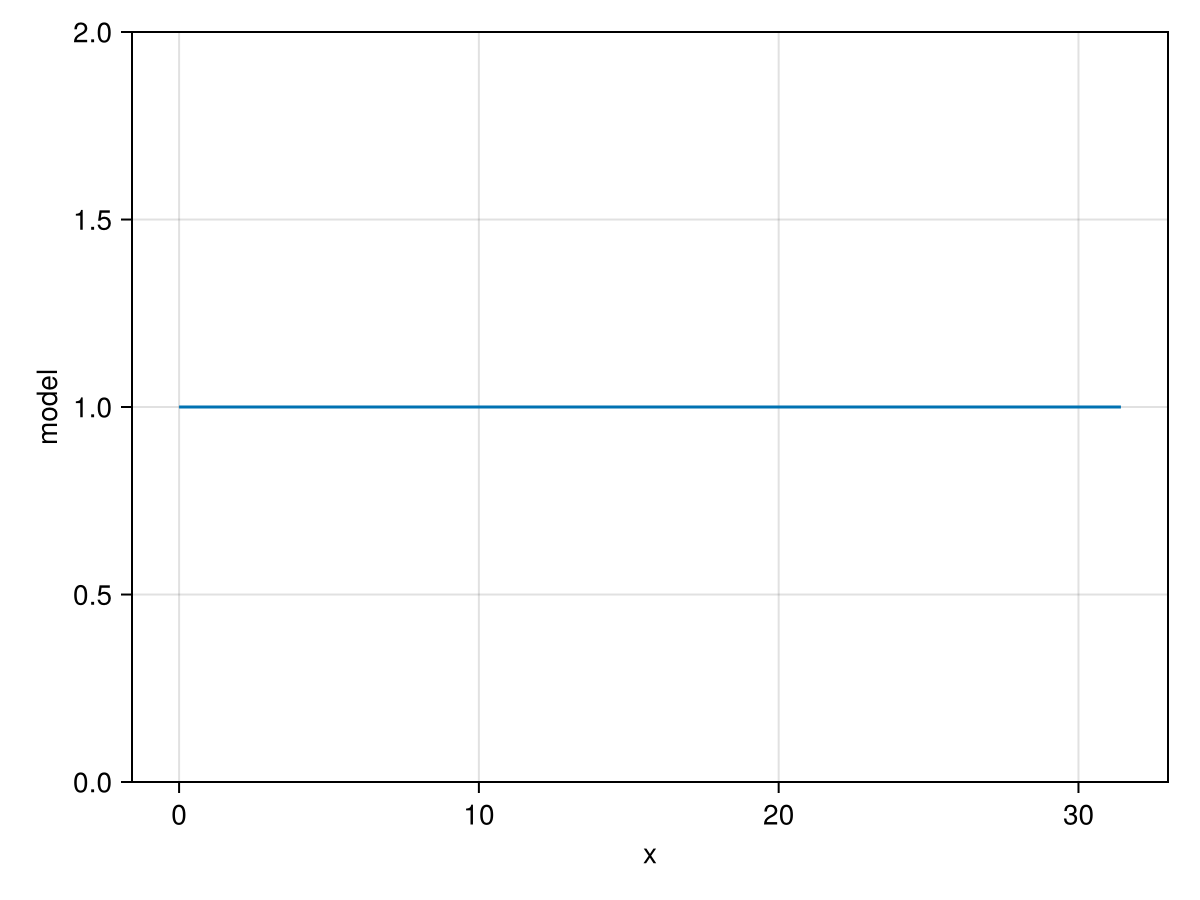

UndefVarError: UndefVarError: `X` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

In [2]:
using Symbolics,CairoMakie
numPointsX = collect(2:2)
logsOfHinverse = [1.0*i for i in 0:4]

cases=[]
#prefix="B"*string(tmpOrderBspace)*"_"*"w"*string(tmpWorderBspace)*"_"*string(tmpSupplementaryOrder)*"_"
prefix=""
L = 10.0*π
cases = push!(cases,(name=prefix*"λ_2",u=cos(x),β= 1))

@variables x
∂ = Differential(x)


misfit = Array{Float64,3}(undef,length(logsOfHinverse),length(cases),length(numPointsX))

modelFamily=[]

fig = Figure()
ax = Axis(fig[1, 1], xlabel="x", ylabel="model")
iH=5
for iCase ∈ eachindex(cases)
    name,_,β = cases[iCase]
    ΔxTry = exp(-logsOfHinverse[iH])
    Nx = Int(L÷ΔxTry) +1
    Δx = L/(Nx-1)
    X = [Δx * (i-1) for i ∈ range(1,Nx)]
    model=[Symbolics.value(substitute(β,Dict(x=>X[i]))) for i ∈ range(1,Nx)]
    lines!(ax, X, model)
end
display(fig)
Nx=nothing
Δx=nothing
iH=nothing
for iCase ∈ eachindex(cases)
    name,_,β = cases[iCase]
    

    for iH ∈ eachindex(logsOfHinverse)
        modelName = name*string(Nx)
        ΔxTry = exp(-logsOfHinverse[iH])
        Nx = Int(L÷ΔxTry) +1
        Δx = L/(Nx-1)
        X = [Δx * (i-1) for i ∈ range(1,Nx)]
        models=[]
        model=[Symbolics.value(substitute(β,Dict(x=>X[i]))) for i ∈ range(1,Nx)]
        models=push!(models, model)
        modelPoints = (Nx)
        tmpModel = (models=models, modelName=modelName, modelPoints=modelPoints)
        modelFamily=push!(modelFamily,tmpModel)
    end

   
end

for iPointsUsed ∈ eachindex(numPointsX), iCase ∈ eachindex(cases), iH ∈ eachindex(logsOfHinverse)
    name,u,β = cases[iCase]
    
    models=modelFamily[iCase]
    q = mySimplify(β*∂(u))
    qₓ = mySimplify(∂(q))
    
    iExperiment = (iH=iH,iCase=iCase,iPointsUsed=iPointsUsed)
    
    force = [Symbolics.value(substitute(qₓ,Dict(x=>X[i]))) for i ∈ range(1,Nx)]
    

    

    
end


# input parameters

In [3]:

famousEquationType="1DpoissonHetero" #GT98
Δ = (1.0)

1.0

In [4]:


# orders: -1 -> indicator function, 0 -> box car, >=1 -> B-spline

orderBtime=1
orderBspace=1

pointsInSpace=3
pointsInTime=3

# the order of errors to be controlled
supplementaryOrder=2

# new parameters for interpolated Taylor expansion μ for field

fieldItpl = (ptsSpace = 1,ptsTime = 1,offsetSpace=1,offsetTime=1,YorderBspace=1,YorderBtime=1) #offsetSpace and offsetTime ∈ z 
# μ points should be distributed from y_min+offset*Δy to y_max-offset*Δy offset can be negative too


# new parameters for interpolated Taylor expansion μᶜ for material
materItpl = (ptsSpace = 1,ptsTime = 1,offsetSpace=1,offsetTime=1,YorderBspace=1,YorderBtime=1)



(ptsSpace = 1, ptsTime = 1, offsetSpace = 1, offsetTime = 1, YorderBspace = 1, YorderBtime = 1)

In [5]:
concreteParametersForOPTConstruction = @strdict famousEquationType Δ orderBtime orderBspace pointsInSpace pointsInTime supplementaryOrder fieldItpl materItpl


Dict{String, Any} with 9 entries:
  "fieldItpl"          => (ptsSpace = 1, ptsTime = 1, offsetSpace = 1, offsetTi…
  "Δ"                  => 1.0
  "supplementaryOrder" => 2
  "materItpl"          => (ptsSpace = 1, ptsTime = 1, offsetSpace = 1, offsetTi…
  "orderBspace"        => 1
  "orderBtime"         => 1
  "famousEquationType" => "1DpoissonHetero"
  "pointsInSpace"      => 3
  "pointsInTime"       => 3

In [6]:
optRec=myProduceOrLoad(makeOPTsemiSymbolic,concreteParametersForOPTConstruction,"semiSymbolic")

Dict{String, Any} with 2 entries:
  "gitcommit" => "c69609f9c80755006ae856b105881f4abe7a2a63-dirty"
  "recette"   => (lhs = (Ajiννᶜ = Num[0.5κ₁ + 0.5κ₂; -0.5κ₁ - κ₂ - 0.5κ₃; 0.5κ₂…

In [7]:
length(modelFamily[1].models[1])

32

In [8]:
costRes=quasiNumericalOperatorConstruction(optRec,modelFamily[1])

size(models[iVar]) = (32,)
newCoords = expandVectors(size(models[iVar]), CartesianDependency) = [32, 1]
ModelPoints[:, iVar] = newCoords = [32, 1]
tmpModel = reshape(models[iVar], newCoords...) = [1; 1; 1; 1; 1; 1; 1; 1; 1; 1; 1; 1; 1; 1; 1; 1; 1; 1; 1; 1; 1; 1; 1; 1; 1; 1; 1; 1; 1; 1; 1; 1;;]
Models[iVar] = tmpModel = [1; 1; 1; 1; 1; 1; 1; 1; 1; 1; 1; 1; 1; 1; 1; 1; 1; 1; 1; 1; 1; 1; 1; 1; 1; 1; 1; 1; 1; 1; 1; 1;;]
(Models, ModelPoints) = (Any[[1; 1; 1; 1; 1; 1; 1; 1; 1; 1; 1; 1; 1; 1; 1; 1; 1; 1; 1; 1; 1; 1; 1; 1; 1; 1; 1; 1; 1; 1; 1; 1;;]], [32; 1;;])


(costFunctions = Any[-2.0var"T_mod_t=1₁" + var"T_mod_t=1₂" var"T_mod_t=1₁" - 2.0var"T_mod_t=1₂" + var"T_mod_t=1₃" … var"T_mod_t=1₃₀" - 2.0var"T_mod_t=1₃₁" + var"T_mod_t=1₃₂" var"T_mod_t=1₃₁" - 2.0var"T_mod_t=1₃₂"], 場 = Any[Num[var"T_mod_t=1₁", var"T_mod_t=1₂", var"T_mod_t=1₃", var"T_mod_t=1₄", var"T_mod_t=1₅", var"T_mod_t=1₆", var"T_mod_t=1₇", var"T_mod_t=1₈", var"T_mod_t=1₉", var"T_mod_t=1₁₀"  …  var"T_mod_t=1₂₃", var"T_mod_t=1₂₄", var"T_mod_t=1₂₅", var"T_mod_t=1₂₆", var"T_mod_t=1₂₇", var"T_mod_t=1₂₈", var"T_mod_t=1₂₉", var"T_mod_t=1₃₀", var"T_mod_t=1₃₁", var"T_mod_t=1₃₂"];;], champsLimité = nothing)

In [9]:
costRes.costFunctions[3]

var"T_mod_t=1₂" - 2.0var"T_mod_t=1₃" + var"T_mod_t=1₄"

In [10]:
optRec["recette"].lhs.Ajiννᶜ

3×1×1×1 Array{Num, 4}:
[:, :, 1, 1] =
              0.50000006κ₁ + 0.5κ₂
 -0.50000006κ₁ - κ₂ - 0.50000006κ₃
              0.5κ₂ + 0.50000006κ₃